### TO DO

In [32]:
1+1

2

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import griddata
# import xesmf as xe
from pathlib import Path
import cartopy.crs as ccrs
import netCDF4  
import time
# import mpl_toolkits.basemap
# import pyresample
import utils as u

In [2]:
year_list = ["2003"]#,"2004","2005","2006","2007","2008","2009","2010","2011","2012","2013"]
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]

In [3]:
# Domain study: Fedchenko, GRa
longitude=slice(66,78)
latitude=slice(36,42)
# temp_HMA=ds.sel(lat=lat,lon=lon)

#### Load MAR outputs

In [4]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRf.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

In [6]:
print('Fedchenko domain')
print('lon min',ds_grF.LON.values.min(),'lon max',ds_grF.LON.values.max())
print('lat min',ds_grF.LAT.values.min(),'lat max',ds_grF.LAT.values.max())

latlim_grF=slice(ds_grF.LAT.values.min(),ds_grF.LAT.values.max())
lonlim_grF=slice(ds_grF.LON.values.min(),ds_grF.LON.values.max())

Fedchenko domain
lon min 67.45302 lon max 77.20667
lat min 36.148087 lat max 41.407486


In [8]:
sourceData='/bettik/amoryc/MARout/GRf/spin3_ICEmask/work/'
variable='TT' ##RF;SF;SHSN3;TT

fileNameF='mon-'+variable+'-MARv3.14_ER5-2003-2013.nc'
dsF= xr.open_dataset(sourceData+fileNameF)

In [9]:
dsF.data_vars[variable]

<xarray.DataArray 'TT' (TIME: 132, ATMLAY: 2, Y: 116, X: 164)>
[5022336 values with dtype=float32]
Coordinates:
  * TIME     (TIME) datetime64[ns] 2003-01-16T12:00:00 ... 2013-12-16T12:00:00
  * X        (X) float32 -405.0 -400.0 -395.0 -390.0 ... 395.0 400.0 405.0 410.0
  * Y        (Y) float32 -285.0 -280.0 -275.0 -270.0 ... 275.0 280.0 285.0 290.0
  * ATMLAY   (ATMLAY) float32 0.9992 0.9996
Attributes:
    long_name:     Temperature
    units:         C
    cell_methods:  TIME: mean
    history:       From ICE.f00.2003.01.01-31

In [10]:
dsF_TT=dsF['TT'][:,0,:,:]
dsF_TT

<xarray.DataArray 'TT' (TIME: 132, Y: 116, X: 164)>
[2511168 values with dtype=float32]
Coordinates:
  * TIME     (TIME) datetime64[ns] 2003-01-16T12:00:00 ... 2013-12-16T12:00:00
  * X        (X) float32 -405.0 -400.0 -395.0 -390.0 ... 395.0 400.0 405.0 410.0
  * Y        (Y) float32 -285.0 -280.0 -275.0 -270.0 ... 275.0 280.0 285.0 290.0
    ATMLAY   float32 0.9992
Attributes:
    long_name:     Temperature
    units:         C
    cell_methods:  TIME: mean
    history:       From ICE.f00.2003.01.01-31

In [12]:
# MAR dataset
folder = '/bettik/amoryc/MARout/GRf/spin3_ICEmask/work/'

# Surface temperature
t2m_yr = xr.open_dataset(folder+'year-TT-MARv3.14_ER5-2003-2013.nc')['TT'][:,0,:,:]
t2m_mon = xr.open_dataset(folder+'mon-TT-MARv3.14_ER5-2003-2013.nc')['TT'][:,0,:,:]

# Rain
wpr_yr = xr.open_dataset(folder+ 'year-RF-MARv3.14_ER5-2003-2013.nc')['RF'][:,:,:]
wpr_mon = xr.open_dataset(folder+ 'mon-RF-MARv3.14_ER5-2003-2013.nc')['RF'][:,:,:]

# Snow fall
spr_yr = xr.open_dataset(folder+ 'year-SF-MARv3.14_ER5-2003-2013.nc')['SF'][:,:,:]
spr_mon = xr.open_dataset(folder+ 'mon-SF-MARv3.14_ER5-2003-2013.nc')['SF'][:,:,:]

# Snow height 
sh_yr = xr.open_dataset(folder+ 'year-SHSN3-MARv3.14_ER5-2003-2013.nc')['SHSN3'][:,:,:,0] 
sh_mon = xr.open_dataset(folder+ 'mon-SHSN3-MARv3.14_ER5-2003-2013.nc')['SHSN3'][:,:,:,0]

### Load Observations

In [9]:
# CRU, APHRODITE SNOW-CCI => Maria a déjà tout sur Spirit

In [13]:
# CRU : Surface mean/min/max températures, clouds
folder_cru='/bettik/PROJECTS/pr-regional-climate/observations/CRU/'

tmp_cru = xr.open_mfdataset(folder_cru + '*.tmp.dat.nc', combine='by_coords', parallel=True).sel(lat=latlim_grF,lon=lonlim_grF).tmp.load()
tmn_cru = xr.open_mfdataset(folder_cru + '*.tmn.dat.nc', combine='by_coords', parallel=True).sel(lat=latlim_grF,lon=lonlim_grF).tmn.load()
tmx_cru = xr.open_mfdataset(folder_cru + '*.tmx.dat.nc', combine='by_coords', parallel=True).sel(lat=latlim_grF,lon=lonlim_grF).tmx.load()
cld_cru = xr.open_mfdataset(folder_cru + '*.cld.dat.nc', combine='by_coords', parallel=True).sel(lat=latlim_grF,lon=lonlim_grF).cld.load()

(240, 11, 19)


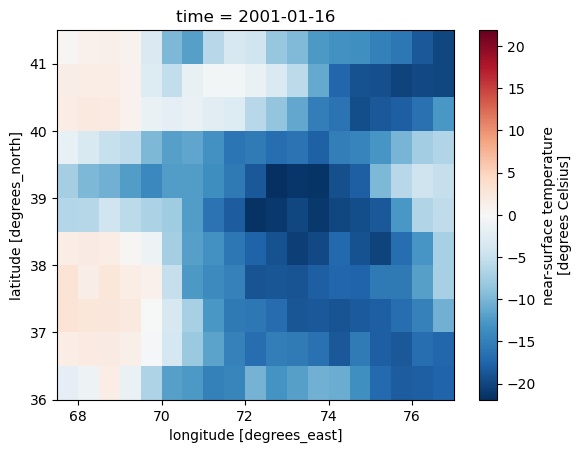

In [18]:
print(tmp_cru.shape)
tmp_cru[0,:,:].plot()

### Load ERA5

In [21]:
folder_era5 = '/bettik/PROJECTS/pr-regional-climate/observations/ERA5/'
ds_era5 = xr.open_mfdataset(folder_era5 + 'ERA5_GRa_t2m.nc')

### Load ERA5-Land

In [22]:
folder_era5_land='/bettik/PROJECTS/pr-regional-climate/observations/ERA5-land/'
ds_era5_land = xr.open_mfdataset(folder_era5_land + 'era5_land_GRa.nc')
ds_era5_land = ds_era5_land.rename({'latitude': 'lat','longitude':'lon'})
ds_era5_land_t2m=ds_era5_land.t2m

In [26]:
ds_era5_land_t2m[:,0,:]

<xarray.DataArray 't2m' (valid_time: 132, lon: 121)>
dask.array<getitem, shape=(132, 121), dtype=float32, chunksize=(132, 121), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2003-01-01 2003-02-01 ... 2013-12-01
    lat         float64 42.0
  * lon         (lon) float64 66.0 66.1 66.2 66.3 66.4 ... 77.7 77.8 77.9 78.0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      7381
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0
    coordinates:                              number time latitude longitude ...

### First Plot

In [11]:
plt.figure(figsize=(8, 6))  
mesh = plt.pcolormesh(t2m_yr_regrid.TT.isel(TIME=0).isel(ATMLAY=1), cmap='RdBu_r')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pamir Mountains - 2003")

# levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 
# contours = plt.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)

# # labels sur les courbes de niveau
# plt.clabel(contours, inline=True, fontsize=8, fmt='%d m') 

# cbar = plt.colorbar(mesh)
# cbar.set_label("Mean annual temperature (°C)")

plt.show()

NameError: name 't2m_yr_regrid' is not defined

<Figure size 800x600 with 0 Axes>

/tmp/ipykernel_3008518/518340548.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = plt.pcolormesh(ds_grF.LON, ds_grF.LAT, t2m_yr.isel(TIME=0), cmap='RdBu_r')


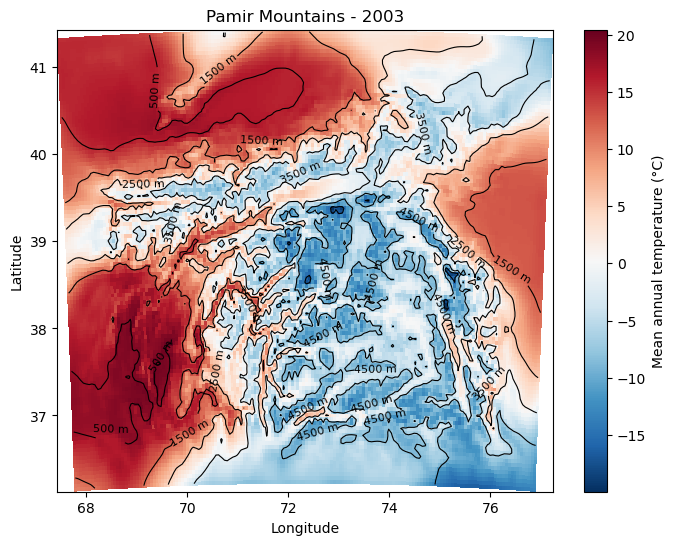

In [17]:
plt.figure(figsize=(8, 6))  
mesh = plt.pcolormesh(ds_grF.LON, ds_grF.LAT, t2m_yr.isel(TIME=0), cmap='RdBu_r')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pamir Mountains - 2003")

levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 
contours = plt.contour(ds_grF.LON, ds_grF.LAT, ds_grF.SH, levels=levels, colors='black', linewidths=0.8)

# labels sur les courbes de niveau
plt.clabel(contours, inline=True, fontsize=8, fmt='%d m') 

cbar = plt.colorbar(mesh)
cbar.set_label("Mean annual temperature (°C)")

plt.show()

# Seasonnal variability

## Surface Temperature

#### Add comparison with CRU, ERA5, including differences (MAR-CRU..)

In [92]:
#A travailler : interpolation entre grilles lat/lon et MAR

t2m_mon_regrid = t2m_mon.TT.isel(ATMLAY=1).interp(lat=tmx_cru['lat'], lon = tmx_cru['lon'])

ValueError: Dimensions {'lat', 'lon'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'TIME': 132, 'X': 164, 'Y': 116})

In [ ]:
nrows=4
ncols=3



fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(10, 14)) 
j=0
k=0

column_titles = ["MAR", "CRU", "Difference MAR - CRU"]
row_titles = season_list


for i, ax in enumerate(axes.flat):
    if (i) % 3 == 0 : 
        m = ax.pcolormesh(coord.LON, coord.LAT,t2m_mon.TT.isel(ATMLAY=1).groupby("TIME.season").mean('TIME').sel(season=season_list[j]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
        j=j+1
    elif (i-1) % 3 == 0 : 
         m = ax.pcolormesh(tmp_cru['lon'], tmp_cru['lat'],tmp_cru.groupby("time.season").mean('time').sel(season=season_list[k]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
         k=k+1
        
        
    levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m
    contours = ax.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=6, fmt='%d m')

for col in range(ncols):
    axes[0, col].set_title(column_titles[col], fontsize=12, fontweight='bold')
for row in range(nrows):
    fig.text(0.02, 0.78 - row * 0.22, row_titles[row], fontsize=12, fontweight='bold', rotation=90, va='center')

    
fig.suptitle('Mean seasonnal (2003-2014) surface temperature : MAR vs CRU', fontsize=12)

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7]) 
fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', label='Temperature (°C)')

plt.tight_layout()
plt.show()

#### Comparing MAR and ERA5-LAND

In [30]:
x_new = ds_era5_land_t2m.lon.values
x_new.shape

(121,)

In [31]:
from scipy.interpolate import bisplrep, bisplev

#Fedchenko
lon = np.array(ds_grF.LON[:,:])
lat = np.array(ds_grF.LAT[:,:])
x = lon.ravel()
y = lat.ravel()
z=t2m_yr[0,:,:].values.ravel()

print(len(x),len(y),len(z))
tck = bisplrep(y, x, z)

19024 19024 19024


In [27]:
x_new = ds_era5_land_t2m.lon.values ##longitudes OBS grid that you want to interpolate to 
y_new = ds_era5_land_t2m.lat.values  ##latitudes OBS grid that you want to interpolate to 
z_new = bisplev(y_new, x_new, tck) 

##Define the new interpolated xarray
ds_era5_land_t2m_interp= xr.DataArray(z_new, dims=ds_era5_land_t2m[0,:,:].dims, coords=ds_era5_land_t2m[0,:,:].coords)

ValueError: Invalid input data

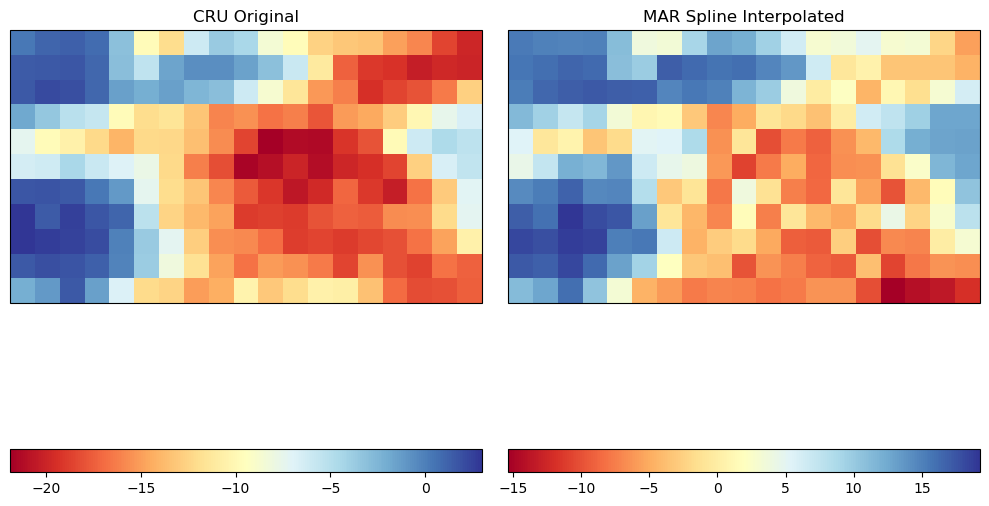

In [75]:
cmap='RdYlBu'
clevs=np.arange(-20,20,2)
vmin=-20 #np.min(Z)
vmax=20 #np.max(Z)

fig, axs = plt.subplots(nrows=1,ncols=2,subplot_kw={'projection': ccrs.PlateCarree()},figsize=(10,10))

m0=axs[0].pcolormesh(tmp_cru.lon, tmp_cru.lat,tmp_cru[0,:,:],cmap=cmap,vmin=np.min(tmp_cru[0,:,:]), vmax=np.max(tmp_cru[0,:,:]))
axs[0].set_title('CRU Original')
fig.colorbar(m0,orientation='horizontal', ax=axs[0])

m1=axs[1].pcolormesh(tmp_cru_interp.lon, tmp_cru_interp.lat, tmp_cru_interp,cmap=cmap,vmin=np.min(tmp_cru_interp), vmax=np.max(tmp_cru_interp))
axs[1].set_title('MAR Spline Interpolated')
fig.colorbar(m1, orientation='horizontal',ax=axs[1])


#ax1.set_title('contourf with levels')
fig.tight_layout()

plt.show()

In [74]:
t2m_mon.Y

<xarray.DataArray 'Y' (Y: 116)> Size: 464B
array([-285., -280., -275., -270., -265., -260., -255., -250., -245., -240.,
       -235., -230., -225., -220., -215., -210., -205., -200., -195., -190.,
       -185., -180., -175., -170., -165., -160., -155., -150., -145., -140.,
       -135., -130., -125., -120., -115., -110., -105., -100.,  -95.,  -90.,
        -85.,  -80.,  -75.,  -70.,  -65.,  -60.,  -55.,  -50.,  -45.,  -40.,
        -35.,  -30.,  -25.,  -20.,  -15.,  -10.,   -5.,    0.,    5.,   10.,
         15.,   20.,   25.,   30.,   35.,   40.,   45.,   50.,   55.,   60.,
         65.,   70.,   75.,   80.,   85.,   90.,   95.,  100.,  105.,  110.,
        115.,  120.,  125.,  130.,  135.,  140.,  145.,  150.,  155.,  160.,
        165.,  170.,  175.,  180.,  185.,  190.,  195.,  200.,  205.,  210.,
        215.,  220.,  225.,  230.,  235.,  240.,  245.,  250.,  255.,  260.,
        265.,  270.,  275.,  280.,  285.,  290.], dtype=float32)
Coordinates:
  * Y        (Y) float32 464B -285.0 -280.0 -275.0 -270.0 ... 280.0 285.0 290.0
Attributes:
    long_name:  y
    units:      km
    axis:       Y

In [26]:
lats = t2m_mon.Y
lons = t2m_mon.X
ds_era5_land_regrid = ds_era5_land.interp(latitude=lats).interp(longitude=lons)
ds_era5_land_regrid.isel(valid_time=1).isel(X=1).isel(Y=1).t2m

<xarray.DataArray 't2m' ()>
dask.array<getitem, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    valid_time  datetime64[ns] 2003-02-01
    latitude    float32 -280.0
    Y           float32 -280.0
    longitude   float32 -400.0
    X           float32 -400.0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      7381
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0
    coordinates:                              number time latitude longitude ...

/tmp/ipykernel_3898849/2450784132.py:11: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(ds_grF.LON, ds_grF.LAT,t2m_mon.TT.isel(ATMLAY=0).groupby("TIME.season").mean('TIME').sel(season=season_list[j]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
/tmp/ipykernel_3898849/2450784132.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(ds_grF.LON, ds_grF.LAT, ds_era5_land_regrid.t2m.groupby("valid_time.season").mean('valid_time').sel(season=season_list[l])-273.15, cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
/tmp/ipykernel_3898849/245078413

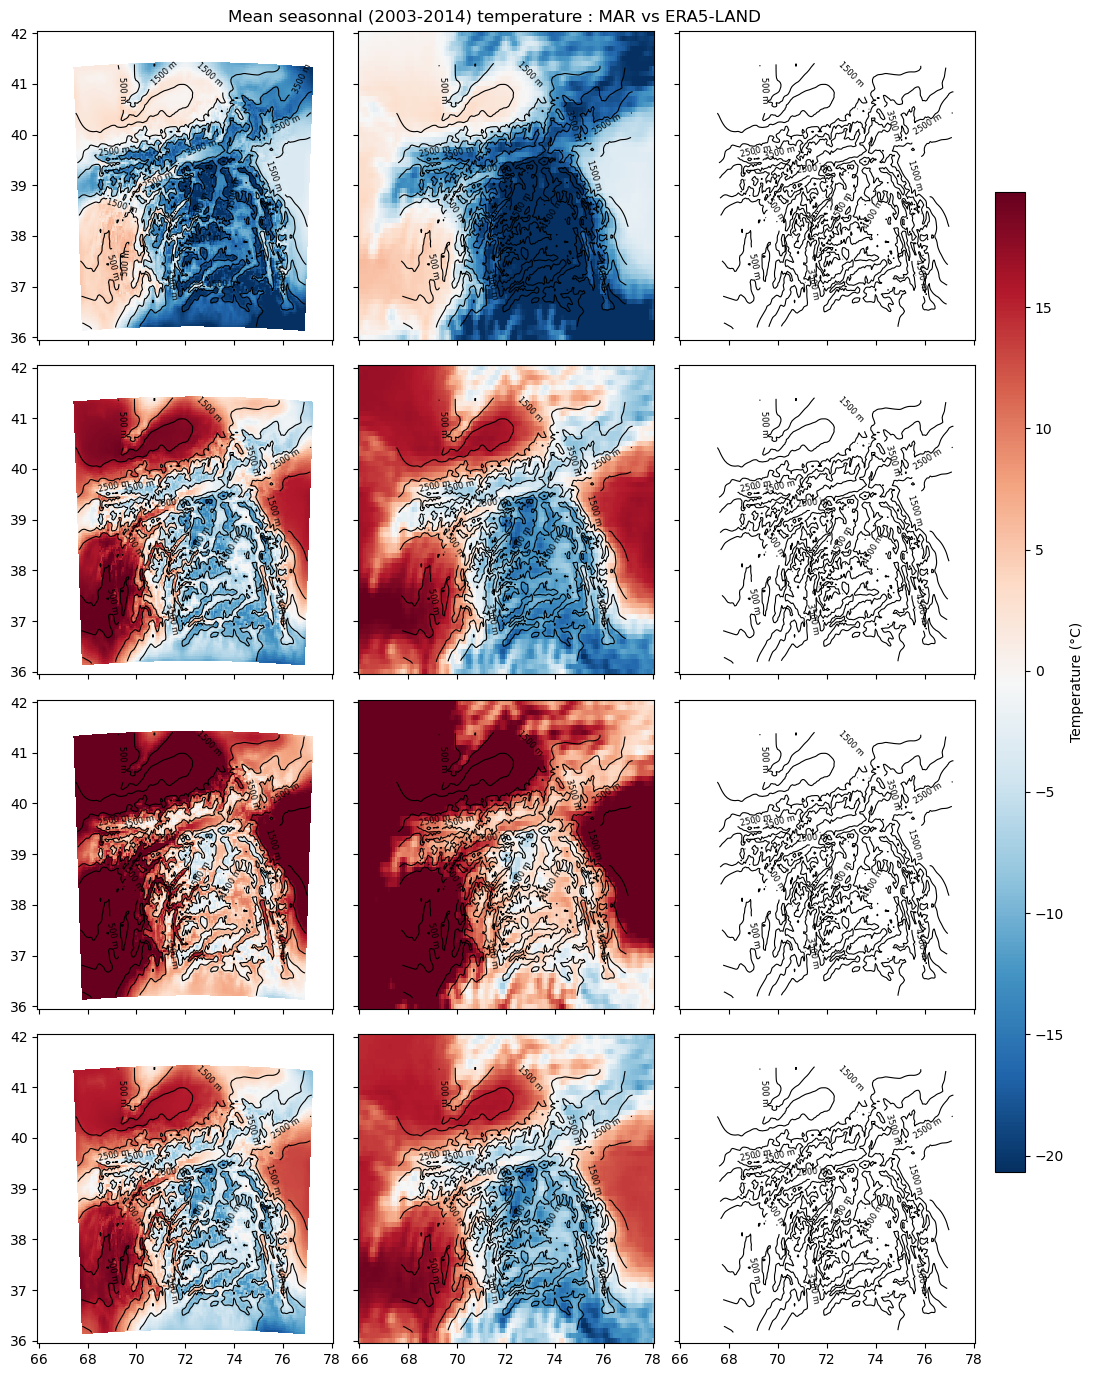

In [27]:
nrows=4
ncols=3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(10, 14)) 
j=0
k=0
l=0

for i, ax in enumerate(axes.flat):
    if (i) % 3 == 0 : 
        m = ax.pcolormesh(ds_grF.LON, ds_grF.LAT,t2m_mon.TT.isel(ATMLAY=1).groupby("TIME.season").mean('TIME').sel(season=season_list[j]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
        j=j+1
    elif (i-1) % 3 == 0 : 
         m = ax.pcolormesh(ds_era5_land['longitude'], ds_era5_land['latitude'], ds_era5_land.t2m.groupby("valid_time.season").mean('valid_time').sel(season=season_list[k])-273.15, cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
         k=k+1
    elif (i-2) % 3 == 0 : 
         m = ax.pcolormesh(ds_grF.LON, ds_grF.LAT, ds_era5_land_regrid.t2m.groupby("valid_time.season").mean('valid_time').sel(season=season_list[l])-273.15, cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
         l=l+1
        
# ds_era5.t.isel(valid_time=1).isel(pressure_level=0).plot()
    levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m
    contours = ax.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=6, fmt='%d m')
    
fig.suptitle('Mean seasonnal (2003-2014) temperature : MAR vs ERA5-LAND', fontsize=12)

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7]) 
fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', label='Temperature (°C)')

plt.tight_layout()
plt.show()

#### Comparing MAR and ERA5

/tmp/ipykernel_507469/1986612807.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(coord.LON, coord.LAT,t2m_mon.TT.isel(ATMLAY=0).groupby("TIME.season").mean('TIME').sel(season=season_list[j]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
/tmp/ipykernel_507469/1986612807.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(coord.LON, coord.LAT,t2m_mon.TT.isel(ATMLAY=0).groupby("TIME.season").mean('TIME').sel(season=season_list[j]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
/tmp/ipykernel_507469/1986612807.py:12: UserWarning: The

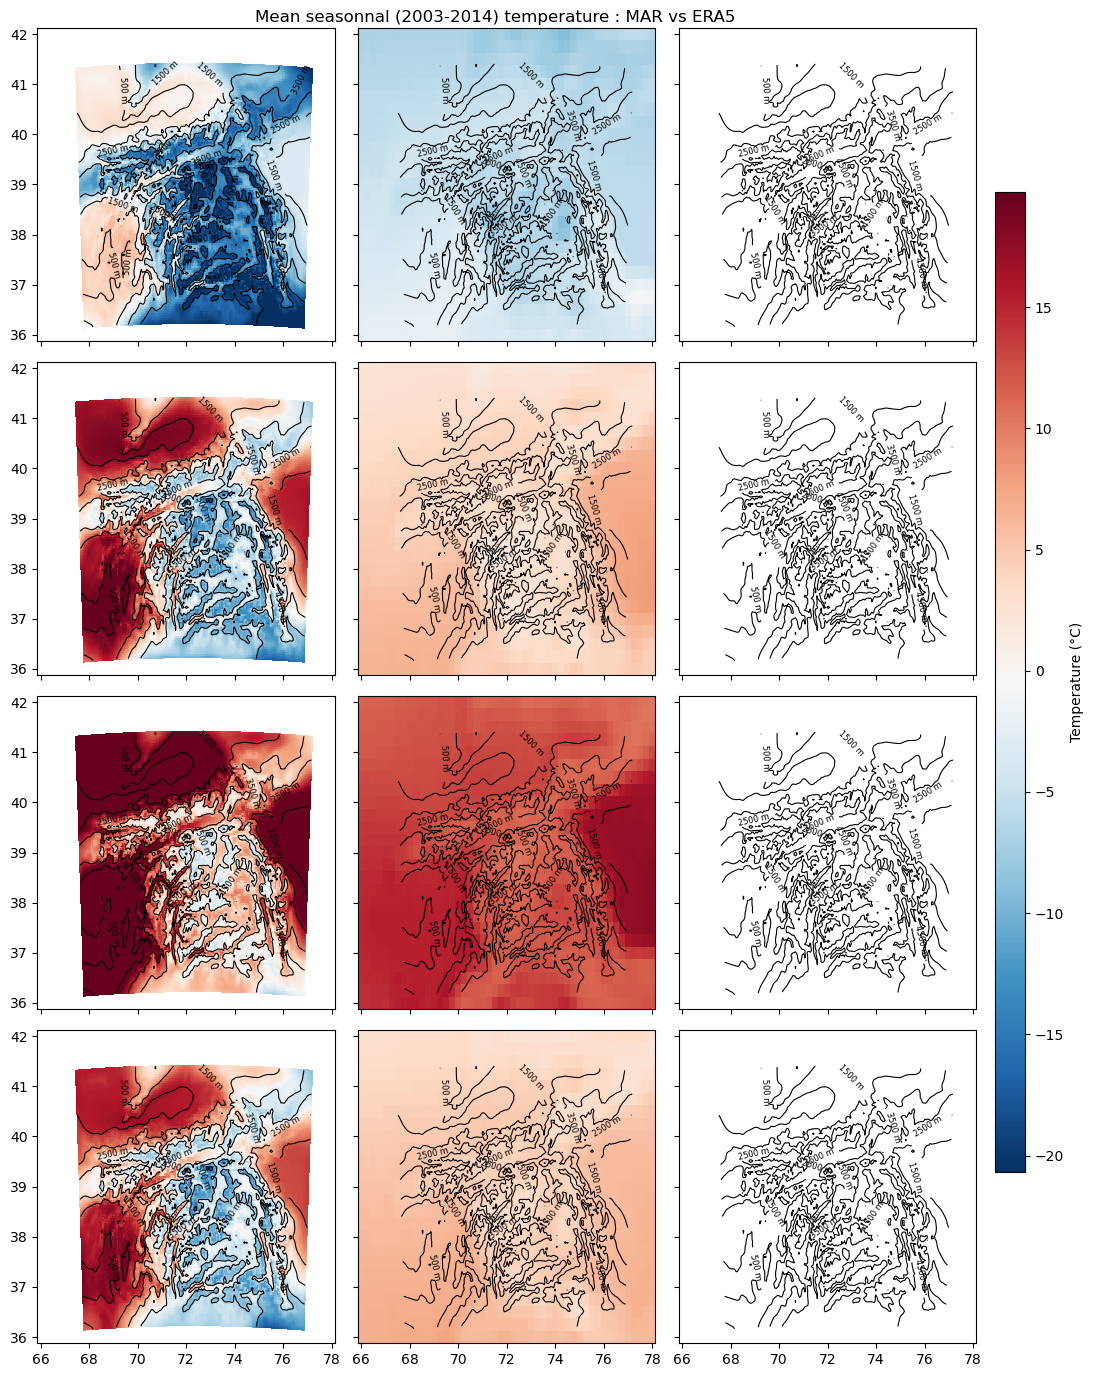

In [18]:
#Vérifier le sens de 'pressure_level'

nrows=4
ncols=3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(10, 14)) 
j=0
k=0

for i, ax in enumerate(axes.flat):
    if (i) % 3 == 0 : 
        m = ax.pcolormesh(coord.LON, coord.LAT,t2m_mon.TT.isel(ATMLAY=1).groupby("TIME.season").mean('TIME').sel(season=season_list[j]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
        j=j+1
    elif (i-1) % 3 == 0 : 
         m = ax.pcolormesh(ds_era5['longitude'], ds_era5['latitude'], ds_era5.t.isel(pressure_level=10).groupby("valid_time.season").mean('valid_time').sel(season=season_list[k])-273.15, cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
         k=k+1
        
# ds_era5.t.isel(valid_time=1).isel(pressure_level=0).plot()
    levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m
    contours = ax.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=6, fmt='%d m')
    
fig.suptitle('Mean seasonnal (2003-2014) temperature : MAR vs ERA5', fontsize=12)

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7]) 
fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', label='Temperature (°C)')

plt.tight_layout()
plt.show()

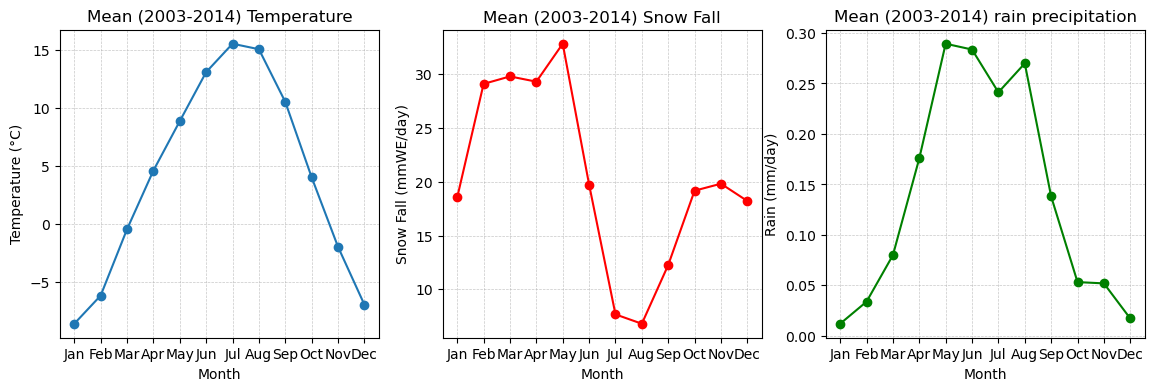

In [19]:
#Ajouter une dépendance à l'altitude

nrows=1
ncols=3

fig, ax = plt.subplots(nrows=nrows, ncols=ncols,  figsize=(14, 4)) 

ax[0].plot(t2m_mon.TT.isel(ATMLAY=1).groupby('TIME.month').mean('TIME').mean(('X', 'Y')),marker='o', linestyle='-')

ax[0].set_xticks(np.arange(0, 12))
ax[0].set_xticklabels(month_list)

ax[0].set_xlabel("Month")
ax[0].set_ylabel("Temperature (°C)")
ax[0].set_title("Mean (2003-2014) Temperature")
ax[0].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

ax[1].plot(spr_mon.SF.groupby('TIME.month').mean('TIME').mean(('X', 'Y')),marker='o', linestyle='-', color = 'r')

ax[1].set_xticks(np.arange(0, 12))
ax[1].set_xticklabels(month_list)

ax[1].set_xlabel("Month")
ax[1].set_ylabel("Snow Fall (mmWE/day)")
ax[1].set_title("Mean (2003-2014) Snow Fall")
ax[1].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

ax[2].plot(wpr_mon.RF.groupby('TIME.month').mean('TIME').mean(('X', 'Y')),marker='o', linestyle='-', color = 'g')

ax[2].set_xticks(np.arange(0, 12))
ax[2].set_xticklabels(month_list)

ax[2].set_xlabel("Month")
ax[2].set_ylabel("Rain (mm/day)")
ax[2].set_title("Mean (2003-2014) rain precipitation")
ax[2].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.show()

## Snow Pack Characteristics

##### Need to include comparison with SNOW-CCI

/tmp/ipykernel_507469/1796893423.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(coord.LON, coord.LAT,sh_mon.SHSN3.groupby("TIME.season").mean('TIME').isel(SECTOR=1).sel(season=season_list[i]), shading='auto',  vmin=0, vmax=8)
/tmp/ipykernel_507469/1796893423.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(coord.LON, coord.LAT,sh_mon.SHSN3.groupby("TIME.season").mean('TIME').isel(SECTOR=1).sel(season=season_list[i]), shading='auto',  vmin=0, vmax=8)
/tmp/ipykernel_507469/1796893423.py:7: UserWarning: The input coordinates to pcolorm

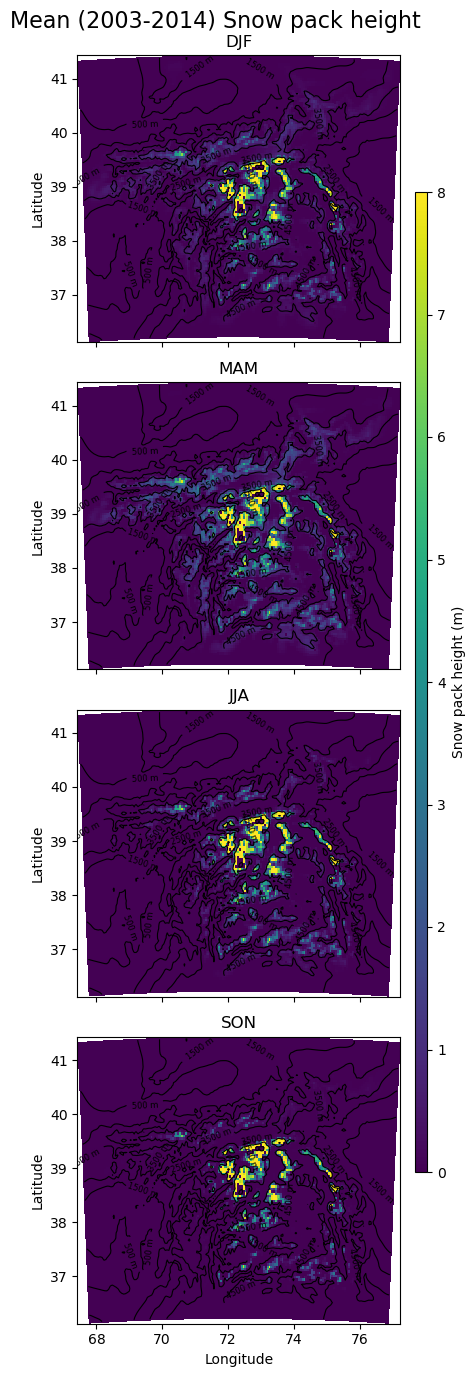

In [20]:
nrows=4
ncols=1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(4, 14)) 

for i, ax in enumerate(axes.flat):
    mesh = ax.pcolormesh(coord.LON, coord.LAT,sh_mon.SHSN3.groupby("TIME.season").mean('TIME').isel(SECTOR=1).sel(season=season_list[i]), shading='auto',  vmin=0, vmax=8)
    
    levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m
    contours = ax.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=6, fmt='%d m')
    
    ax.set_title(season_list[i]) 
    ax.set_ylabel('Latitude') 
    # if i % 5 == 0:
    #     axs[i].set_ylabel("Latitude")
    if i >= 3:
        ax.set_xlabel("Longitude")

fig.suptitle('Mean (2003-2014) Snow pack height', fontsize=16)

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7]) 
fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', label='Snow pack height (m)')

plt.tight_layout()
plt.show()

In [21]:
1+1

2